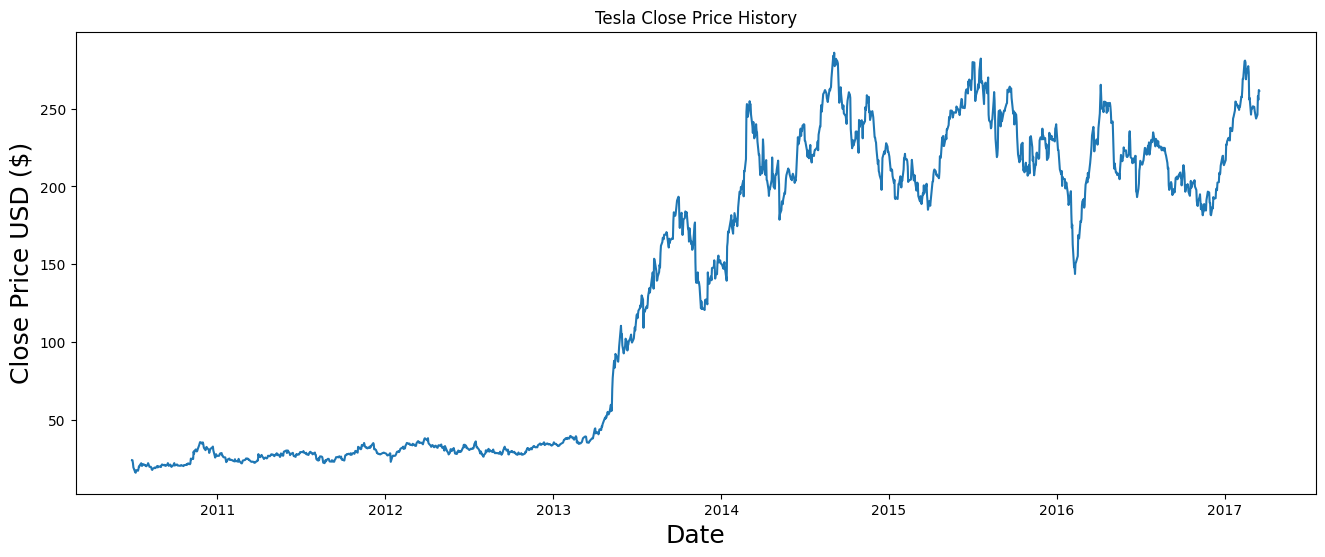

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - loss: 0.0055
Epoch 2/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - loss: 0.0029
Epoch 3/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - loss: 0.0025
Epoch 4/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - loss: 0.0021
Epoch 5/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - loss: 0.0022
Epoch 6/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - loss: 0.0023
Epoch 7/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - loss: 0.0020
Epoch 8/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - loss: 0.0020
Epoch 9/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - loss: 0.0018
Epoch 10/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - loss: 0.0017
Epoch 11/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - loss: 0.0017
Epoch 12/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - loss: 0.0016
Epoch 13/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - loss: 0.0016
Epoch 14/25
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - loss: 0.0016
E

/tmp/ipykernel_2057/2855417401.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


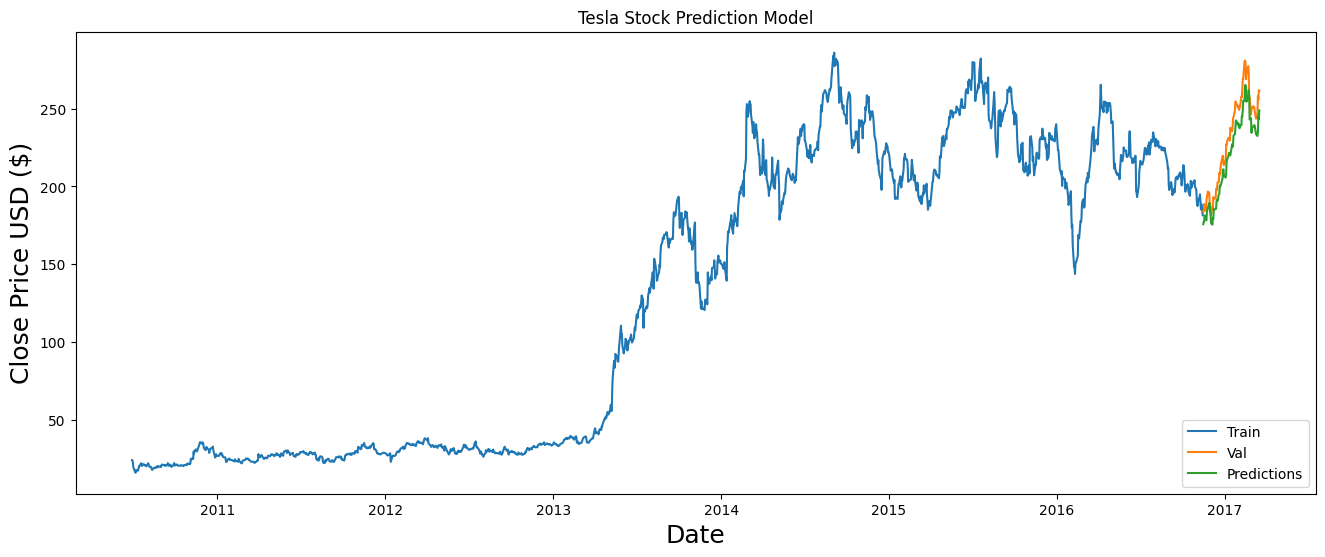

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# 1. Load the data
df = pd.read_csv('tesla.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# 2. Visualize the closing price
plt.figure(figsize=(16,6))
plt.title('Tesla Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

# 3. Prepare and scale the data
data = df.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil(len(dataset) * .95))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# 4. Build the 60-day training windows
train_data = scaled_data[0:training_data_len, :]
x_train, y_train = [], []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# 5. Build and train the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=25)

# 6. Prepare test data
test_data = scaled_data[training_data_len - 60:, :]
x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# 7. Predict and evaluate
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
print("RMSE:", rmse)

# 8. Plot actual vs predicted
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Tesla Stock Prediction Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()